In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## load dataset

In [3]:
df=pd.read_csv("covid_19_data.csv")

df.head()

,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,01/22/2020,Gujarat,India,2020-01-22 00:00:00,982,19,81
1,01/23/2020,Gujarat,India,2020-01-23 00:00:00,1137,33,352
2,01/24/2020,Gujarat,India,2020-01-24 00:00:00,1608,41,706
3,01/25/2020,Gujarat,India,2020-01-25 00:00:00,2073,46,743
4,01/26/2020,Gujarat,India,2020-01-26 00:00:00,2389,61,930


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ObservationDate  390 non-null    str  
 1   Province/State   390 non-null    str  
 2   Country/Region   390 non-null    str  
 3   Last Update      390 non-null    str  
 4   Confirmed        390 non-null    int64
 5   Deaths           390 non-null    int64
 6   Recovered        390 non-null    int64
dtypes: int64(3), str(4)
memory usage: 21.5 KB


In [4]:
df.isnull().sum()

ObservationDate    0
Province/State     0
Country/Region     0
Last Update        0
Confirmed          0
Deaths             0
Recovered          0
dtype: int64

In [5]:
df.describe()

,Confirmed,Deaths,Recovered
count,390.000000,390.000000,390.000000
mean,4955.248718,165.651282,3386.217949
std,2499.636913,88.307458,1899.875111
min,327.000000,12.000000,81.000000
25%,2809.500000,92.000000,1720.250000
50%,4974.000000,161.500000,3414.500000
75%,7053.500000,239.750000,4982.250000
max,9953.000000,385.000000,7629.000000


In [7]:
country_cases = df.groupby("Country/Region")["Confirmed"].max().sort_values(ascending=False)

print(country_cases.head(10))

Country/Region
India     9953
USA       9678
Brazil    9236
Italy     9212
UK        8970
Name: Confirmed, dtype: int64


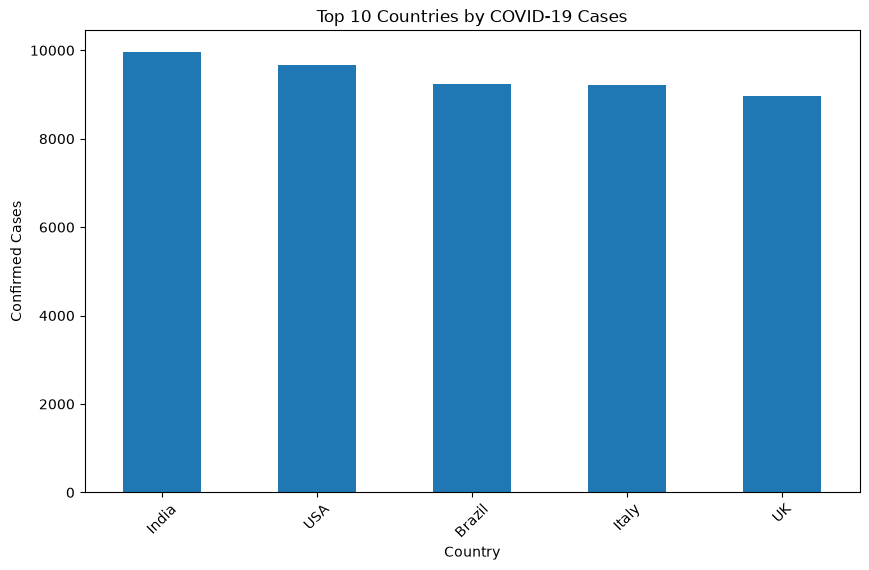

In [8]:
top10 = country_cases.head(10)

plt.figure(figsize=(10, 6))
top10.plot(kind="bar")
plt.title("Top 10 Countries by COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()


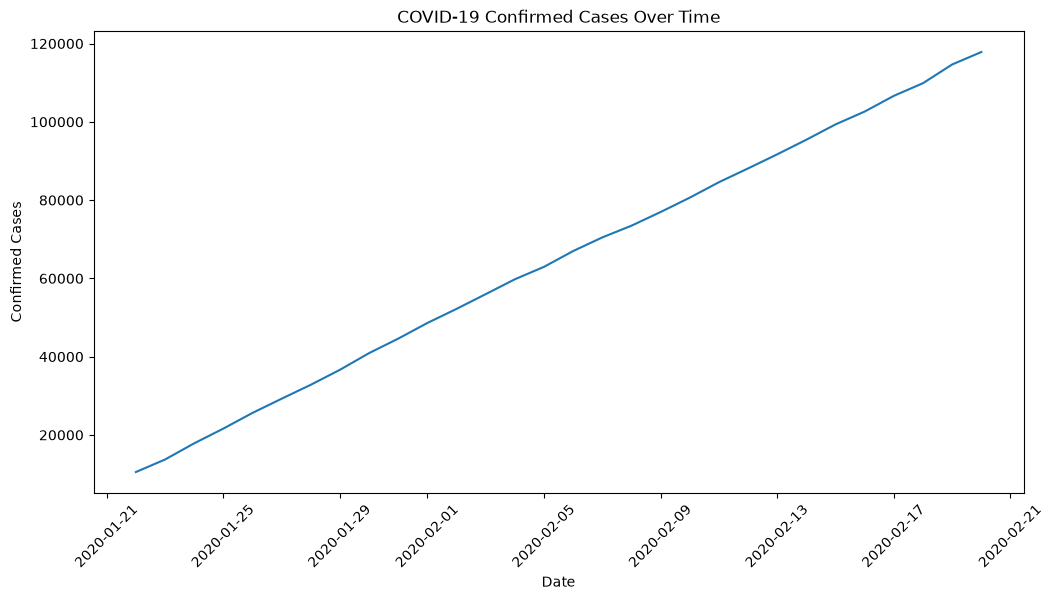

In [9]:
df["ObservationDate"] = pd.to_datetime(df["ObservationDate"])

daily_cases = df.groupby("ObservationDate")["Confirmed"].sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_cases.index, daily_cases.values)
plt.title("COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()


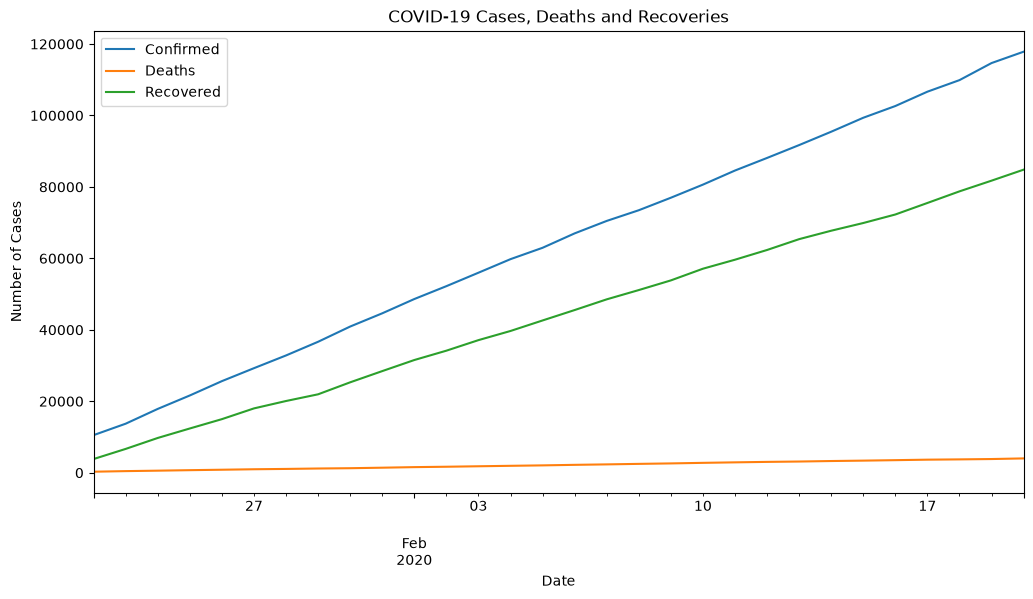

In [10]:
daily_data = df.groupby("ObservationDate")[["Confirmed", "Deaths", "Recovered"]].sum()

daily_data.plot(figsize=(12, 6))
plt.title("COVID-19 Cases, Deaths and Recoveries")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()